In [1]:
import pandas as pd
import numpy as np

In [2]:
import io
import re

def read_geo_series_matrix(file_path: str):
    """
    GEO series_matrix.txt dosyasını:
    - meta: sample bazlı metadata (GSM, title, group, phase, vs.)
    - table: expression/protein intensity matrisi (rows=features, cols=samples)
    olarak döndürür.
    """
    with open(file_path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.read().splitlines()

    # 1) Table kısmını bul
    begin_idx = None
    for i, line in enumerate(lines):
        if line.strip().lower() == "!series_matrix_table_begin":
            begin_idx = i
            break
    if begin_idx is None:
        raise ValueError("!series_matrix_table_begin bulunamadı.")

    # Header satırı: "ID_REF" ... "GSM...."
    header_idx = begin_idx + 1
    while header_idx < len(lines) and not lines[header_idx].strip().startswith('"ID_REF"') and not lines[header_idx].strip().startswith("ID_REF"):
        header_idx += 1
    if header_idx >= len(lines):
        raise ValueError("Table header (ID_REF...) bulunamadı.")

    # Table end
    end_idx = None
    for i in range(header_idx + 1, len(lines)):
        if lines[i].strip().lower() == "!series_matrix_table_end":
            end_idx = i
            break
    if end_idx is None:
        raise ValueError("!series_matrix_table_end bulunamadı.")

    table_text = "\n".join(lines[header_idx:end_idx])
    table = pd.read_csv(io.StringIO(table_text), sep="\t", quotechar='"')

    # ID_REF sütununu temizle (tırnak vs.)
    table.rename(columns={table.columns[0]: "ID_REF"}, inplace=True)
    table["ID_REF"] = table["ID_REF"].astype(str).str.replace('"', '').str.strip()

    # 2) Metadata satırlarını çek (table_begin öncesi)
    meta_block = lines[:begin_idx]

    def get_row(key: str):
        # örn: !Sample_title   "..."  "..."
        for line in meta_block:
            if line.startswith(key + "\t"):
                parts = line.split("\t")
                # ilk eleman key, geri kalanı sample değerleri
                return [p.strip() for p in parts[1:]]
        return None

    sample_titles = get_row("!Sample_title")
    sample_geo = get_row("!Sample_geo_accession")

    # Bazı dosyalarda group bilgisi buradan daha temiz gelir:
    # Phase II dosyasında !Sample_source_name_ch2 içinde "Serum,LungCancer,Phase II" gibi değerler var. :contentReference[oaicite:3]{index=3}
    source_ch2 = get_row("!Sample_source_name_ch2")
    source_ch1 = get_row("!Sample_source_name_ch1")

    # Table sütunlarındaki GSM listesi (ID_REF hariç)
    gsm_cols = [c.strip().replace('"', '') for c in table.columns[1:]]

    # sample_geo bazen GSM listesiyle birebir gelir; gelmiyorsa table GSM'lerini kullanırız
    if sample_geo is not None:
        sample_geo = [x.replace('"','').strip() for x in sample_geo]
    else:
        sample_geo = gsm_cols

    # Title yoksa fallback
    if sample_titles is not None:
        sample_titles = [x.replace('"','').strip() for x in sample_titles]
    else:
        sample_titles = [""] * len(sample_geo)

    # Source yoksa boş
    if source_ch2 is not None:
        source = [x.replace('"','').strip() for x in source_ch2]
    elif source_ch1 is not None:
        source = [x.replace('"','').strip() for x in source_ch1]
    else:
        source = [""] * len(sample_geo)

    meta = pd.DataFrame({
        "GSM": sample_geo,
        "title": sample_titles,
        "source": source
    })

    # 3) Group/phase çıkarımı (title daha güvenli: Serum-XXX-Phase II) :contentReference[oaicite:4]{index=4}
    def parse_group_phase(row):
        txt = (row["title"] or "") + " " + (row["source"] or "")
        txt_low = txt.lower()

        # group
        if "lungcancer" in txt_low:
            group = "LungCancer"
        elif "negativecontrol" in txt_low:
            group = "NegativeControl"
        elif "diseasecontrol" in txt_low:
            group = "DiseaseControl"
        else:
            group = np.nan

        # phase
        if "phase ii" in txt_low or "phaseii" in txt_low:
            phase = "Phase II"
        elif "phase i" in txt_low or "phasei" in txt_low:
            phase = "Phase I"
        else:
            phase = np.nan

        return pd.Series([group, phase])

    meta[["group", "phase"]] = meta.apply(parse_group_phase, axis=1)

    # 4) meta ile table sütunlarını hizala
    # (table'daki GSM'ler kesin doğru; meta'daki GSM ile merge edip sıralayalım)
    meta = meta.merge(pd.DataFrame({"GSM": gsm_cols}), on="GSM", how="right")

    # Ek: 3-class label (0/1/2) + binary label (cancer vs non-cancer)
    class_map = {"NegativeControl": 0, "DiseaseControl": 1, "LungCancer": 2}
    meta["label_3class"] = meta["group"].map(class_map)

    # binary: sadece LungCancer=1, diğerleri=0
    meta["label_binary"] = meta["group"].apply(lambda g: 1 if g == "LungCancer" else (0 if g in ["NegativeControl","DiseaseControl"] else np.nan))

    return meta, table


# --- Phase I ve Phase II dosyalarını oku ---
file_path_phase1 = "GSE168198-GPL29809_series_matrix.txt"
file_path_phase2 = "GSE168198-GPL29810_series_matrix.txt"

meta_p1, table_p1 = read_geo_series_matrix(file_path_phase1)
meta_p2, table_p2 = read_geo_series_matrix(file_path_phase2)

print("Phase I:", table_p1.shape, meta_p1["group"].value_counts(dropna=False))
print("Phase II:", table_p2.shape, meta_p2["group"].value_counts(dropna=False))


Phase I: (46066, 17) group
NegativeControl    8
LungCancer         8
Name: count, dtype: int64
Phase II: (182, 181) group
DiseaseControl     60
LungCancer         60
NegativeControl    60
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

# X: table -> sample x feature formatına çevirelim
X_phase2 = table_p2.set_index("ID_REF").T  # satırlar sample, sütunlar protein feature
y_phase2 = meta_p2["label_binary"].values  # cancer=1, non-cancer=0

# NaN varsa (olmaması lazım ama garanti)
mask = ~pd.isna(y_phase2)
X_phase2 = X_phase2.loc[mask]
y_phase2 = y_phase2[mask].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_phase2, y_phase2,
    test_size=0.15,
    random_state=42,
    stratify=y_phase2
)

print(X_train.shape, X_test.shape, np.bincount(y_train), np.bincount(y_test))


(153, 182) (27, 182) [102  51] [18  9]


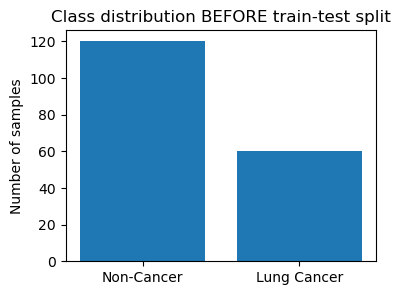

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Split öncesi sınıf dağılımı
unique, counts = np.unique(y_phase2, return_counts=True)

plt.figure(figsize=(4,3))
plt.bar(["Non-Cancer", "Lung Cancer"], counts)
plt.title("Class distribution BEFORE train-test split")
plt.ylabel("Number of samples")
plt.show()

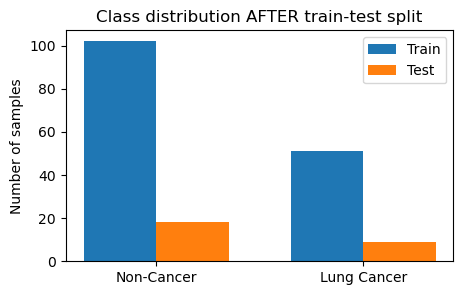

In [17]:
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)

labels = ["Non-Cancer", "Lung Cancer"]
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(5,3))
plt.bar(x - width/2, train_counts, width, label="Train")
plt.bar(x + width/2, test_counts, width, label="Test")

plt.xticks(x, labels)
plt.ylabel("Number of samples")
plt.title("Class distribution AFTER train-test split")
plt.legend()
plt.show()
# “Train and test class ratios overlap completely due to stratified sampling, indicating that class balance was perfectly preserved after the split.”

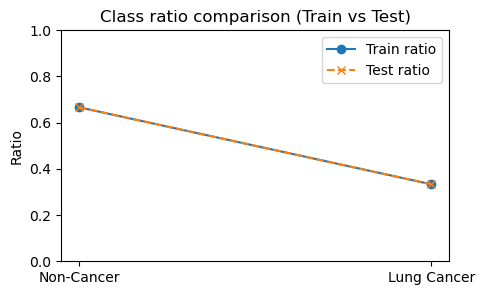

In [18]:
plt.figure(figsize=(5,3))

train_ratio = train_counts / train_counts.sum()
test_ratio  = test_counts  / test_counts.sum()

plt.plot(labels, train_ratio, marker="o", linestyle="-", label="Train ratio")
plt.plot(labels, test_ratio, marker="x", linestyle="--", label="Test ratio")

plt.ylim(0,1)
plt.title("Class ratio comparison (Train vs Test)")
plt.ylabel("Ratio")
plt.legend()
plt.show()

In [22]:
import pandas as pd
import numpy as np
import io

def read_geo_series_matrix(file_path: str):
    with open(file_path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.read().splitlines()

    begin_idx = None
    for i, line in enumerate(lines):
        if line.strip().lower() == "!series_matrix_table_begin":
            begin_idx = i
            break
    if begin_idx is None:
        raise ValueError("!series_matrix_table_begin bulunamadı.")

    header_idx = begin_idx + 1
    while header_idx < len(lines) and not lines[header_idx].strip().startswith('"ID_REF"') and not lines[header_idx].strip().startswith("ID_REF"):
        header_idx += 1
    if header_idx >= len(lines):
        raise ValueError("Table header (ID_REF...) bulunamadı.")

    end_idx = None
    for i in range(header_idx + 1, len(lines)):
        if lines[i].strip().lower() == "!series_matrix_table_end":
            end_idx = i
            break
    if end_idx is None:
        raise ValueError("!series_matrix_table_end bulunamadı.")

    table_text = "\n".join(lines[header_idx:end_idx])
    table = pd.read_csv(io.StringIO(table_text), sep="\t", quotechar='"')

    table.rename(columns={table.columns[0]: "ID_REF"}, inplace=True)
    table["ID_REF"] = table["ID_REF"].astype(str).str.replace('"', '').str.strip()

    meta_block = lines[:begin_idx]

    def get_row(key: str):
        for line in meta_block:
            if line.startswith(key + "\t"):
                parts = line.split("\t")
                return [p.strip() for p in parts[1:]]
        return None

    sample_titles = get_row("!Sample_title")
    sample_geo = get_row("!Sample_geo_accession")
    source_ch2 = get_row("!Sample_source_name_ch2")
    source_ch1 = get_row("!Sample_source_name_ch1")

    gsm_cols = [c.strip().replace('"', '') for c in table.columns[1:]]

    if sample_geo is not None:
        sample_geo = [x.replace('"','').strip() for x in sample_geo]
    else:
        sample_geo = gsm_cols

    if sample_titles is not None:
        sample_titles = [x.replace('"','').strip() for x in sample_titles]
    else:
        sample_titles = [""] * len(sample_geo)

    if source_ch2 is not None:
        source = [x.replace('"','').strip() for x in source_ch2]
    elif source_ch1 is not None:
        source = [x.replace('"','').strip() for x in source_ch1]
    else:
        source = [""] * len(sample_geo)

    meta = pd.DataFrame({"GSM": sample_geo, "title": sample_titles, "source": source})

    def parse_group_phase(row):
        txt = (row["title"] or "") + " " + (row["source"] or "")
        txt_low = txt.lower()

        if "lungcancer" in txt_low:
            group = "LungCancer"
        elif "negativecontrol" in txt_low:
            group = "NegativeControl"
        elif "diseasecontrol" in txt_low:
            group = "DiseaseControl"
        else:
            group = np.nan

        if "phase ii" in txt_low or "phaseii" in txt_low:
            phase = "Phase II"
        elif "phase i" in txt_low or "phasei" in txt_low:
            phase = "Phase I"
        else:
            phase = np.nan

        return pd.Series([group, phase])

    meta[["group", "phase"]] = meta.apply(parse_group_phase, axis=1)

    meta = meta.merge(pd.DataFrame({"GSM": gsm_cols}), on="GSM", how="right")

    class_map = {"NegativeControl": 0, "DiseaseControl": 1, "LungCancer": 2}
    meta["label_3class"] = meta["group"].map(class_map)
    meta["label_binary"] = meta["group"].apply(
        lambda g: 1 if g == "LungCancer" else (0 if g in ["NegativeControl","DiseaseControl"] else np.nan)
    )

    return meta, table

# Dosya yolu (senin upload ettiğin path'ler)
file_path_phase2 = "GSE168198-GPL29810_series_matrix.txt"

meta_p2, table_p2 = read_geo_series_matrix(file_path_phase2)

print("Phase II table shape:", table_p2.shape)
print("Phase II group counts:\n", meta_p2["group"].value_counts(dropna=False))
print("Phase II phase counts:\n", meta_p2["phase"].value_counts(dropna=False))


Phase II table shape: (182, 181)
Phase II group counts:
 group
DiseaseControl     60
LungCancer         60
NegativeControl    60
Name: count, dtype: int64
Phase II phase counts:
 phase
Phase II    180
Name: count, dtype: int64


In [23]:
# X: sample x feature
X_phase2 = table_p2.set_index("ID_REF").T
X_phase2 = X_phase2.apply(pd.to_numeric, errors="coerce")

print("X_phase2 shape:", X_phase2.shape)

# NA kontrolü
print("Any NA at all? ->", X_phase2.isna().any().any())

na_per_sample = X_phase2.isna().mean(axis=1).sort_values(ascending=False)
na_per_feature = X_phase2.isna().mean(axis=0).sort_values(ascending=False)

print("\nTop 5 samples by NA ratio:")
print(na_per_sample.head(5))

print("\nTop 5 features by NA ratio:")
print(na_per_feature.head(5))

# Constant feature kontrolü
n_unique = X_phase2.nunique(dropna=True)
const_features = n_unique[n_unique <= 1]
print("\nNumber of constant (<=1 unique) features:", const_features.shape[0])
if const_features.shape[0] > 0:
    print(const_features.head(10))


X_phase2 shape: (180, 182)
Any NA at all? -> False

Top 5 samples by NA ratio:
GSM5133683    0.0
GSM5133796    0.0
GSM5133798    0.0
GSM5133799    0.0
GSM5133800    0.0
dtype: float64

Top 5 features by NA ratio:
ID_REF
1      0.0
115    0.0
117    0.0
118    0.0
119    0.0
dtype: float64

Number of constant (<=1 unique) features: 0


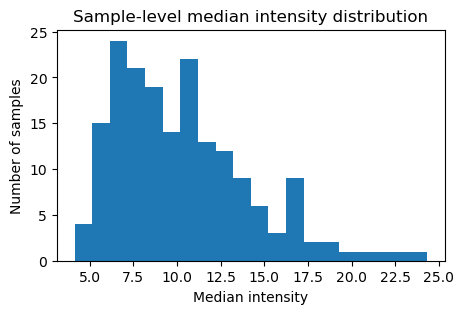

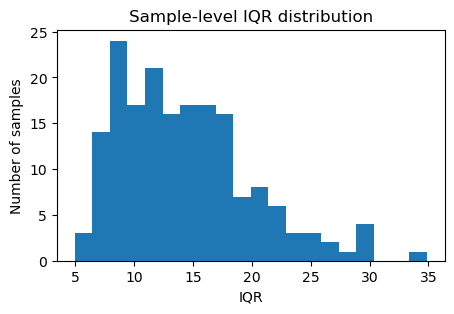

In [24]:
import matplotlib.pyplot as plt

# Sample-level summary statistics
sample_median = X_phase2.median(axis=1)
sample_iqr = X_phase2.quantile(0.75, axis=1) - X_phase2.quantile(0.25, axis=1)

plt.figure(figsize=(5,3))
plt.hist(sample_median, bins=20)
plt.title("Sample-level median intensity distribution")
plt.xlabel("Median intensity")
plt.ylabel("Number of samples")
plt.show()

plt.figure(figsize=(5,3))
plt.hist(sample_iqr, bins=20)
plt.title("Sample-level IQR distribution")
plt.xlabel("IQR")
plt.ylabel("Number of samples")
plt.show()

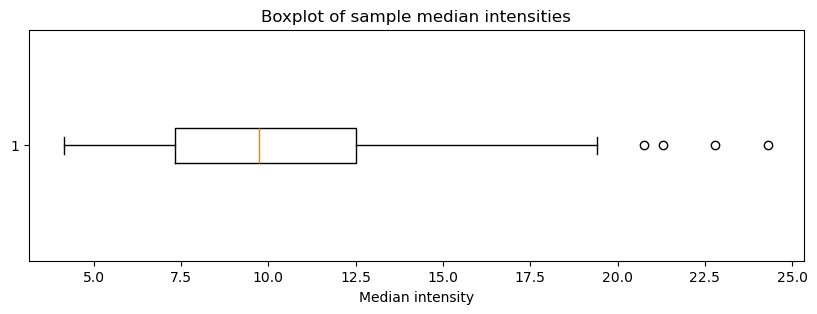

In [26]:
plt.figure(figsize=(10,3))
plt.boxplot(sample_median, vert=False)
plt.title("Boxplot of sample median intensities")
plt.xlabel("Median intensity")
plt.show()

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ID_REF feature'ını geçici olarak çıkar (sayısal ama anlamsız)
X_numeric = X_phase2.copy()
X_numeric = X_numeric.drop(columns=["ID_REF"], errors="ignore")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

In [28]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained (PC1+PC2):", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.18992528 0.10313208]
Total variance explained (PC1+PC2): 0.29305735981676884


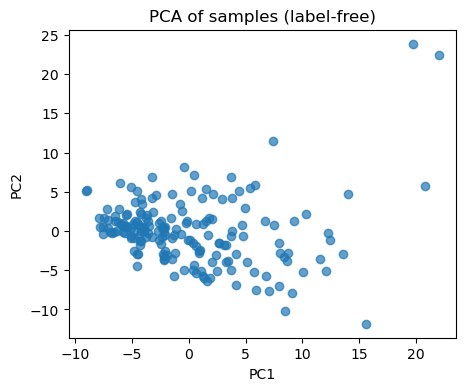

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of samples (label-free)")
plt.show()

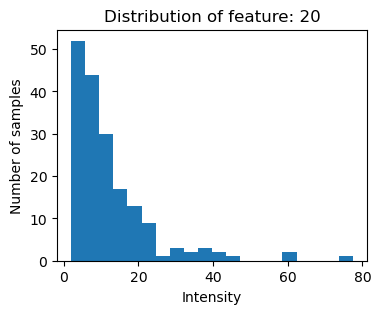

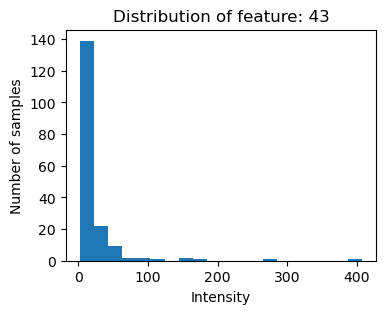

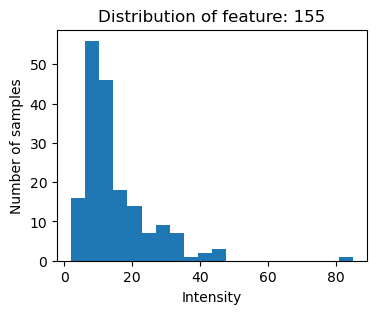

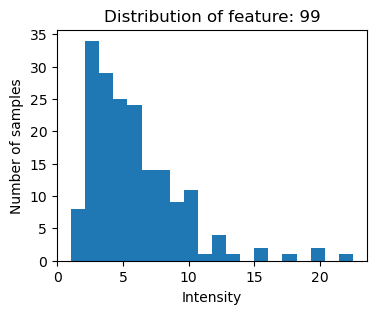

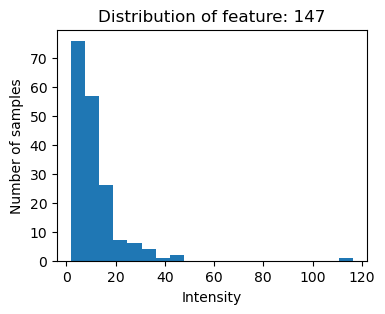

In [30]:
np.random.seed(42)
random_features = np.random.choice(X_numeric.columns, size=5, replace=False)

for feat in random_features:
    plt.figure(figsize=(4,3))
    plt.hist(X_numeric[feat], bins=20)
    plt.title(f"Distribution of feature: {feat}")
    plt.xlabel("Intensity")
    plt.ylabel("Number of samples")
    plt.show()

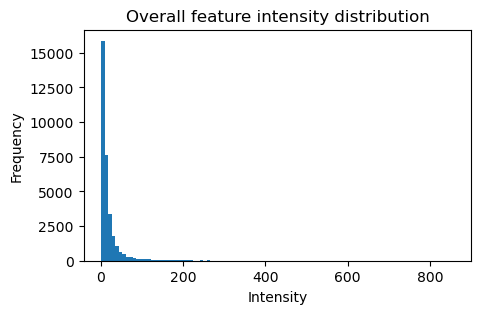

In [31]:
all_values = X_numeric.values.flatten()

plt.figure(figsize=(5,3))
plt.hist(all_values, bins=100)
plt.title("Overall feature intensity distribution")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

In [32]:
# ID_REF hariç sadece sayısal feature'lar
X_log = np.log1p(X_numeric)

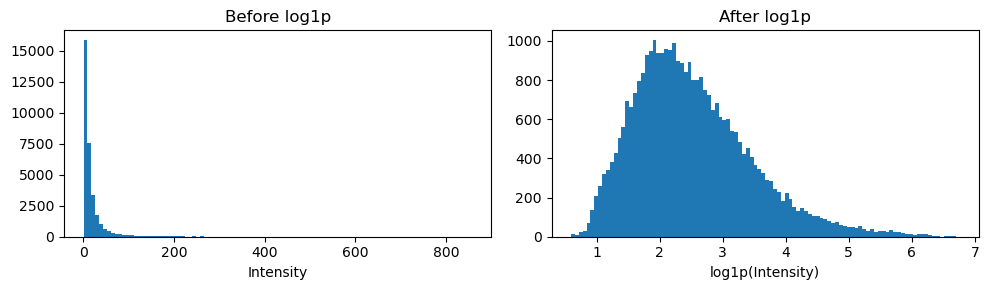

In [33]:
plt.figure(figsize=(10,3))

plt.subplot(1,2,1)
plt.hist(X_numeric.values.flatten(), bins=100)
plt.title("Before log1p")
plt.xlabel("Intensity")

plt.subplot(1,2,2)
plt.hist(X_log.values.flatten(), bins=100)
plt.title("After log1p")
plt.xlabel("log1p(Intensity)")

plt.tight_layout()
plt.show()

Explained variance ratio (log1p PCA): [0.2760997  0.13402645]
Total variance explained: 0.41012614756280263


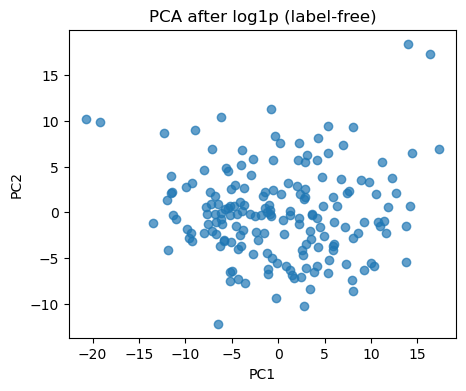

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_log_scaled = scaler.fit_transform(X_log)

pca_log = PCA(n_components=2, random_state=42)
X_log_pca = pca_log.fit_transform(X_log_scaled)

print("Explained variance ratio (log1p PCA):", pca_log.explained_variance_ratio_)
print("Total variance explained:", pca_log.explained_variance_ratio_.sum())

plt.figure(figsize=(5,4))
plt.scatter(X_log_pca[:,0], X_log_pca[:,1], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA after log1p (label-free)")
plt.show()

In [35]:
from sklearn.model_selection import train_test_split

# Label
y = meta_p2["label_binary"].values

# Mask (NaN yok ama garanti)
mask = ~pd.isna(y)

X_all = X_numeric.loc[mask]
y_all = y[mask].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.15,
    random_state=42,
    stratify=y_all
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train class counts:", np.bincount(y_train))
print("Test class counts :", np.bincount(y_test))

Train shape: (153, 182)
Test shape : (27, 182)
Train class counts: [102  51]
Test class counts : [18  9]


In [36]:
# Log1p dönüşümü
X_train_log = np.log1p(X_train)
X_test_log  = np.log1p(X_test)   # sadece transform, fit yok

In [37]:
from sklearn.metrics import roc_auc_score

auc_scores = []

for col in X_train_log.columns:
    try:
        auc = roc_auc_score(y_train, X_train_log[col])
    except ValueError:
        auc = np.nan
    auc_scores.append(auc)

auc_df = pd.DataFrame({
    "feature": X_train_log.columns,
    "auc": auc_scores
}).dropna()

auc_df = auc_df.sort_values("auc", ascending=False)

auc_df.head(10)


,feature,auc
72,73,0.672241
13,14,0.654364
84,85,0.642830
25,26,0.634371
52,53,0.626490
48,49,0.625144
19,20,0.623414
12,13,0.617070
66,67,0.613226
29,30,0.606498


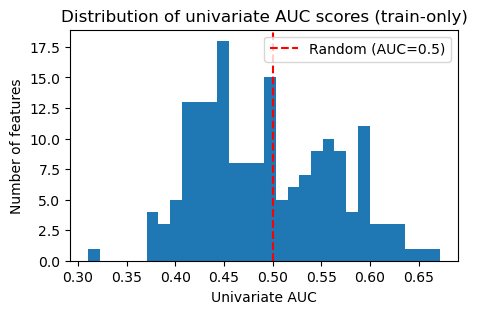

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
plt.hist(auc_df["auc"], bins=30)
plt.axvline(0.5, color="red", linestyle="--", label="Random (AUC=0.5)")
plt.xlabel("Univariate AUC")
plt.ylabel("Number of features")
plt.title("Distribution of univariate AUC scores (train-only)")
plt.legend()
plt.show()

In [39]:
selected_features_auc = auc_df[auc_df["auc"] >= 0.55]["feature"].tolist()

print("Number of selected features (AUC >= 0.55):", len(selected_features_auc))

Number of selected features (AUC >= 0.55): 46


In [40]:
X_train_fs = X_train_log[selected_features_auc]
X_test_fs  = X_test_log[selected_features_auc]

print("Filtered train shape:", X_train_fs.shape)
print("Filtered test shape :", X_test_fs.shape)

Filtered train shape: (153, 46)
Filtered test shape : (27, 46)


In [41]:
from sklearn.feature_selection import mutual_info_classif

# MI hesapla (log1p + train-only)
mi_scores = mutual_info_classif(
    X_train_log,
    y_train,
    random_state=42
)

mi_df = pd.DataFrame({
    "feature": X_train_log.columns,
    "mi": mi_scores
}).sort_values("mi", ascending=False)

mi_df.head(10)

,feature,mi
117,118,0.147757
161,162,0.111868
92,93,0.095992
25,26,0.086570
96,97,0.084976
13,14,0.077728
6,7,0.071722
116,117,0.069140
103,104,0.068466
125,126,0.065671


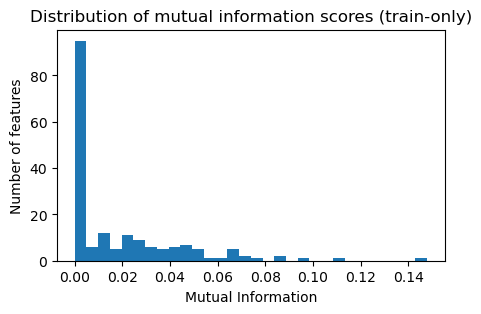

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
plt.hist(mi_df["mi"], bins=30)
plt.xlabel("Mutual Information")
plt.ylabel("Number of features")
plt.title("Distribution of mutual information scores (train-only)")
plt.show()

In [43]:
selected_features_mi = mi_df[mi_df["mi"] > 0]["feature"].tolist()

print("Number of features with MI > 0:", len(selected_features_mi))

Number of features with MI > 0: 99


In [44]:
selected_features_final = list(
    set(selected_features_auc).intersection(set(selected_features_mi))
)

print("Final number of selected features (AUC >= 0.55 ∩ MI > 0):",
      len(selected_features_final))

Final number of selected features (AUC >= 0.55 ∩ MI > 0): 23


In [45]:
X_train_final = X_train_log[selected_features_final]
X_test_final  = X_test_log[selected_features_final]

print("Final train shape:", X_train_final.shape)
print("Final test shape :", X_test_final.shape)

Final train shape: (153, 23)
Final test shape : (27, 23)


In [46]:
# Son feature set
Xtr = X_train_final.copy()
Xte = X_test_final.copy()

ytr = y_train
yte = y_test

print(Xtr.shape, Xte.shape)

(153, 23) (27, 23)


In [47]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

logreg.fit(Xtr, ytr)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [48]:
# Cancer olasılığı (class=1)
ytr_proba_lr = logreg.predict_proba(Xtr)[:, 1]
yte_proba_lr = logreg.predict_proba(Xte)[:, 1]

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(Xtr, ytr)

RandomForestClassifier(min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [50]:
ytr_proba_rf = rf.predict_proba(Xtr)[:, 1]
yte_proba_rf = rf.predict_proba(Xte)[:, 1]

In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Logistic Regression predictions
yte_pred_lr = (yte_proba_lr >= 0.5).astype(int)

# Random Forest predictions
yte_pred_rf = (yte_proba_rf >= 0.5).astype(int)


In [52]:
metrics = []

# Logistic Regression
metrics.append({
    "Model": "Logistic Regression",
    "Precision": precision_score(yte, yte_pred_lr),
    "Recall": recall_score(yte, yte_pred_lr),
    "F1-score": f1_score(yte, yte_pred_lr)
})

# Random Forest
metrics.append({
    "Model": "Random Forest",
    "Precision": precision_score(yte, yte_pred_rf),
    "Recall": recall_score(yte, yte_pred_rf),
    "F1-score": f1_score(yte, yte_pred_rf)
})

metrics_df = pd.DataFrame(metrics)
metrics_df

,Model,Precision,Recall,F1-score
0,Logistic Regression,0.5,0.222222,0.307692
1,Random Forest,0.5,0.111111,0.181818


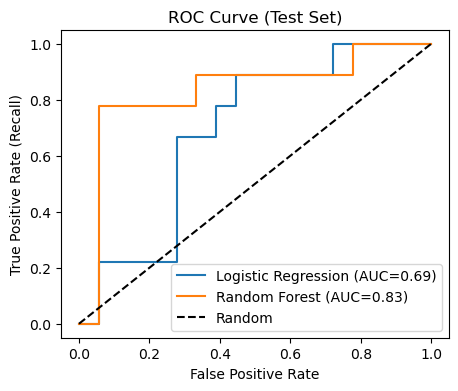

In [53]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(yte, yte_proba_lr)
auc_lr = roc_auc_score(yte, yte_proba_lr)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(yte, yte_proba_rf)
auc_rf = roc_auc_score(yte, yte_proba_rf)

plt.figure(figsize=(5,4))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.2f})")
plt.plot([0,1], [0,1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.show()

In [54]:
thresholds = [0.5, 0.3, 0.2]

rows = []

for t in thresholds:
    y_pred_t = (yte_proba_lr >= t).astype(int)
    
    rows.append({
        "Threshold": t,
        "Precision": precision_score(yte, y_pred_t),
        "Recall": recall_score(yte, y_pred_t),
        "F1-score": f1_score(yte, y_pred_t)
    })

threshold_df = pd.DataFrame(rows)
threshold_df


,Threshold,Precision,Recall,F1-score
0,0.5,0.500000,0.222222,0.307692
1,0.3,0.461538,0.666667,0.545455
2,0.2,0.470588,0.888889,0.615385


In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [56]:
# Threshold'lar
y_pred_05 = (yte_proba_lr >= 0.5).astype(int)
y_pred_02 = (yte_proba_lr >= 0.2).astype(int)

cm_05 = confusion_matrix(yte, y_pred_05)
cm_02 = confusion_matrix(yte, y_pred_02)


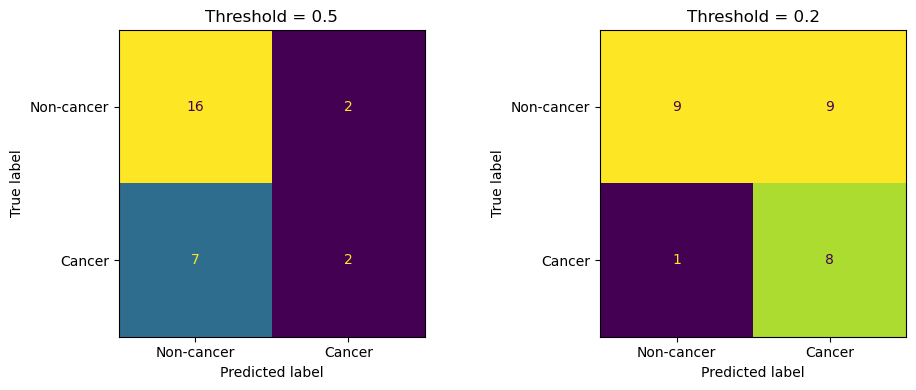

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

disp1 = ConfusionMatrixDisplay(cm_05, display_labels=["Non-cancer", "Cancer"])
disp1.plot(ax=axes[0], values_format="d", colorbar=False)
axes[0].set_title("Threshold = 0.5")

disp2 = ConfusionMatrixDisplay(cm_02, display_labels=["Non-cancer", "Cancer"])
disp2.plot(ax=axes[1], values_format="d", colorbar=False)
axes[1].set_title("Threshold = 0.2")

plt.tight_layout()
plt.show()


In [58]:
import pandas as pd
import numpy as np

# Test set index (GSM id'ler) -> X_test_final'ın index'i sample isimleri
test_ids = X_test_final.index

df_pred = pd.DataFrame({
    "GSM": test_ids,
    "y_true": yte
})

# İnsan okunur etiket
df_pred["true_label"] = df_pred["y_true"].map({0: "Non-cancer", 1: "Cancer"})

# Risk skorları (olasılık)
df_pred["risk_logreg"] = yte_proba_lr
df_pred["risk_rf"]     = yte_proba_rf

# Threshold bazlı kararlar (0/1)
for t in [0.5, 0.2]:
    df_pred[f"pred_lr_{t}"] = (df_pred["risk_logreg"] >= t).astype(int)
    df_pred[f"pred_rf_{t}"] = (df_pred["risk_rf"]     >= t).astype(int)

# Karar etiketleri (pozitif/negatif)
for t in [0.5, 0.2]:
    df_pred[f"pred_lr_label_{t}"] = df_pred[f"pred_lr_{t}"].map({0:"Non-cancer", 1:"Cancer"})
    df_pred[f"pred_rf_label_{t}"] = df_pred[f"pred_rf_{t}"].map({0:"Non-cancer", 1:"Cancer"})

# Confusion-type (TP/FP/TN/FN) fonksiyonu
def confusion_tag(y_true, y_pred):
    if y_true == 1 and y_pred == 1: return "TP"
    if y_true == 0 and y_pred == 1: return "FP"
    if y_true == 0 and y_pred == 0: return "TN"
    if y_true == 1 and y_pred == 0: return "FN"

for t in [0.5, 0.2]:
    df_pred[f"lr_tag_{t}"] = [
        confusion_tag(yt, yp) for yt, yp in zip(df_pred["y_true"], df_pred[f"pred_lr_{t}"])
    ]
    df_pred[f"rf_tag_{t}"] = [
        confusion_tag(yt, yp) for yt, yp in zip(df_pred["y_true"], df_pred[f"pred_rf_{t}"])
    ]

# Riskleri yüzde formatında göstermek istersen
df_pred["risk_logreg_pct"] = (100 * df_pred["risk_logreg"]).round(1)
df_pred["risk_rf_pct"]     = (100 * df_pred["risk_rf"]).round(1)

# Görünüm: en riskli kişileri üste al (LogReg'e göre)
df_pred = df_pred.sort_values("risk_logreg", ascending=False).reset_index(drop=True)

df_pred.head(10)


,GSM,y_true,true_label,risk_logreg,risk_rf,pred_lr_0.5,pred_rf_0.5,pred_lr_0.2,pred_rf_0.2,pred_lr_label_0.5,pred_rf_label_0.5,pred_lr_label_0.2,pred_rf_label_0.2,lr_tag_0.5,rf_tag_0.5,lr_tag_0.2,rf_tag_0.2,risk_logreg_pct,risk_rf_pct
0,GSM5133703,0,Non-cancer,0.843906,0.416457,1,0,1,1,Cancer,Non-cancer,Cancer,Cancer,FP,TN,FP,FP,84.4,41.6
1,GSM5133770,1,Cancer,0.833791,0.473726,1,0,1,1,Cancer,Non-cancer,Cancer,Cancer,TP,FN,TP,TP,83.4,47.4
2,GSM5133783,1,Cancer,0.555956,0.494266,1,0,1,1,Cancer,Non-cancer,Cancer,Cancer,TP,FN,TP,TP,55.6,49.4
3,GSM5133697,0,Non-cancer,0.543390,0.566765,1,1,1,1,Cancer,Cancer,Cancer,Cancer,FP,FP,FP,FP,54.3,56.7
4,GSM5133734,0,Non-cancer,0.404092,0.281998,0,0,1,1,Non-cancer,Non-cancer,Cancer,Cancer,TN,TN,FP,FP,40.4,28.2
5,GSM5133846,0,Non-cancer,0.403428,0.201734,0,0,1,1,Non-cancer,Non-cancer,Cancer,Cancer,TN,TN,FP,FP,40.3,20.2
6,GSM5133862,0,Non-cancer,0.379509,0.190163,0,0,1,0,Non-cancer,Non-cancer,Cancer,Non-cancer,TN,TN,FP,TN,38.0,19.0
7,GSM5133754,1,Cancer,0.357708,0.526422,0,1,1,1,Non-cancer,Cancer,Cancer,Cancer,FN,TP,TP,TP,35.8,52.6
8,GSM5133781,1,Cancer,0.344684,0.466798,0,0,1,1,Non-cancer,Non-cancer,Cancer,Cancer,FN,FN,TP,TP,34.5,46.7
9,GSM5133749,1,Cancer,0.342689,0.469384,0,0,1,1,Non-cancer,Non-cancer,Cancer,Cancer,FN,FN,TP,TP,34.3,46.9


In [59]:
cols = [
    "GSM", "true_label",
    "risk_logreg_pct", "pred_lr_label_0.2", "lr_tag_0.2",
    "risk_rf_pct",     "pred_rf_label_0.5", "rf_tag_0.5"
]
df_pred[cols]


,GSM,true_label,risk_logreg_pct,pred_lr_label_0.2,lr_tag_0.2,risk_rf_pct,pred_rf_label_0.5,rf_tag_0.5
0,GSM5133703,Non-cancer,84.4,Cancer,FP,41.6,Non-cancer,TN
1,GSM5133770,Cancer,83.4,Cancer,TP,47.4,Non-cancer,FN
2,GSM5133783,Cancer,55.6,Cancer,TP,49.4,Non-cancer,FN
3,GSM5133697,Non-cancer,54.3,Cancer,FP,56.7,Cancer,FP
4,GSM5133734,Non-cancer,40.4,Cancer,FP,28.2,Non-cancer,TN
5,GSM5133846,Non-cancer,40.3,Cancer,FP,20.2,Non-cancer,TN
6,GSM5133862,Non-cancer,38.0,Cancer,FP,19.0,Non-cancer,TN
7,GSM5133754,Cancer,35.8,Cancer,TP,52.6,Cancer,TP
8,GSM5133781,Cancer,34.5,Cancer,TP,46.7,Non-cancer,FN
9,GSM5133749,Cancer,34.3,Cancer,TP,46.9,Non-cancer,FN


In [60]:
df_pred.to_csv("test_predictions_risk_table.csv", index=False)
print("Saved: test_predictions_risk_table.csv")


Saved: test_predictions_risk_table.csv
